In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Step 1: Load the Dataset

In [2]:
df=pd.read_csv('train.csv')

In [3]:
print(df.head())

   id Driver Compound                   Race  Year  PitStop  LapNumber  Stint  \
0   0   D109     HARD    Canadian Grand Prix  2022        0         50      2   
1   1   D086     HARD       Dutch Grand Prix  2025        1         27      2   
2   2    ZON     HARD    Austrian Grand Prix  2022        0         59      3   
3   3    SPE   MEDIUM     Pre-Season Testing  2023        0          2      1   
4   4   D019     HARD  Azerbaijan Grand Prix  2022        1         26      3   

   TyreLife  Position  LapTime (s)  LapTime_Delta  Cumulative_Degradation  \
0      39.0         8       78.491         -7.564                  21.019   
1       7.0         4       75.095        -32.617                -223.207   
2      22.0        13       70.945         -7.540                -100.529   
3       2.0         7       94.361         -7.324                  -7.324   
4       6.0         2      107.878          8.965                 -14.139   

   RaceProgress  Position_Change  PitNextLap  
0  

In [4]:
print(df.columns.tolist())

['id', 'Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'PitNextLap']


In [5]:
print(df.columns)

Index(['id', 'Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber',
       'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta',
       'Cumulative_Degradation', 'RaceProgress', 'Position_Change',
       'PitNextLap'],
      dtype='object')


### Step 2: Understand the Dataset

In [6]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  object 
 2   Compound                439140 non-null  object 
 3   Race                    439140 non-null  object 
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            439140 non-null  float64
 14  Position_Change     

,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,219569.500000,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,126768.942943,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,0.000000,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,109784.750000,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,219569.500000,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,329354.250000,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000
max,439139.000000,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000


### Step 3: Check Missing Values

In [7]:
df.isnull().sum()

id                        0
Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
PitNextLap                0
dtype: int64

### Step 4: Check Duplicate Values

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.drop_duplicates(inplace=True)

### Step 5: Separate Numerical and Categorical Columns

In [11]:
num_cols = df.select_dtypes(include='number')
cat_cols = df.select_dtypes(exclude='number')

In [12]:
print(num_cols)

            id  Year  PitStop  LapNumber  Stint  TyreLife  Position  \
0            0  2022        0         50      2      39.0         8   
1            1  2025        1         27      2       7.0         4   
2            2  2022        0         59      3      22.0        13   
3            3  2023        0          2      1       2.0         7   
4            4  2022        1         26      3       6.0         2   
...        ...   ...      ...        ...    ...       ...       ...   
439135  439135  2023        0         49      2       8.0        17   
439136  439136  2023        0         49      2       5.0         1   
439137  439137  2023        0         49      2      18.0         1   
439138  439138  2023        0         48      3      10.0         1   
439139  439139  2023        0         49      2      32.0         1   

        LapTime (s)  LapTime_Delta  Cumulative_Degradation  RaceProgress  \
0            78.491         -7.564                  21.019      0.71428

In [13]:
print(cat_cols)

       Driver Compound                   Race
0        D109     HARD    Canadian Grand Prix
1        D086     HARD       Dutch Grand Prix
2         ZON     HARD    Austrian Grand Prix
3         SPE   MEDIUM     Pre-Season Testing
4        D019     HARD  Azerbaijan Grand Prix
...       ...      ...                    ...
439135   D755   MEDIUM       Miami Grand Prix
439136   D731   MEDIUM       Miami Grand Prix
439137   D716   MEDIUM       Miami Grand Prix
439138   D665     HARD   Abu Dhabi Grand Prix
439139   D714     HARD       Miami Grand Prix

[439140 rows x 3 columns]


### Step 6: UniVariate Analysis

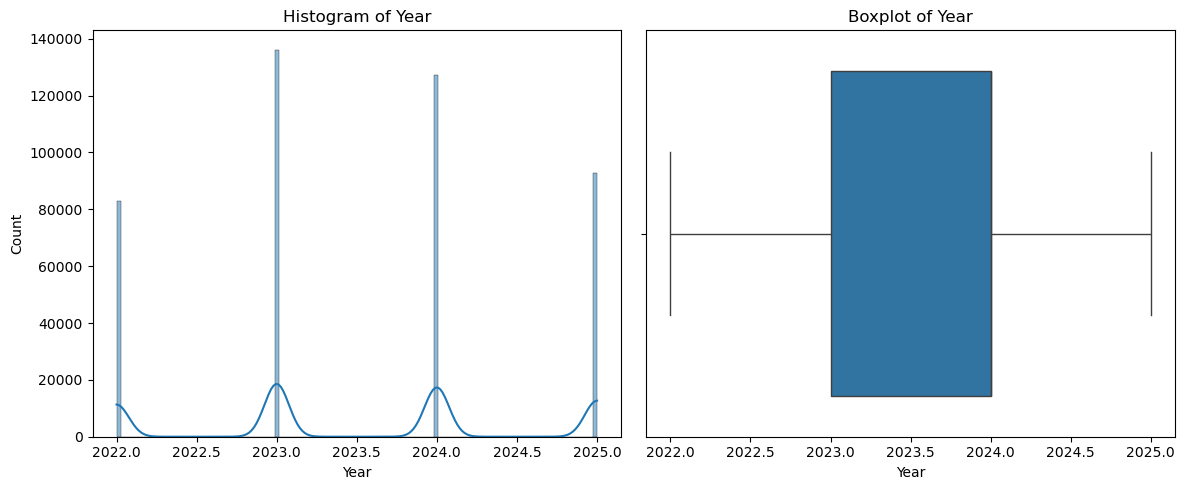

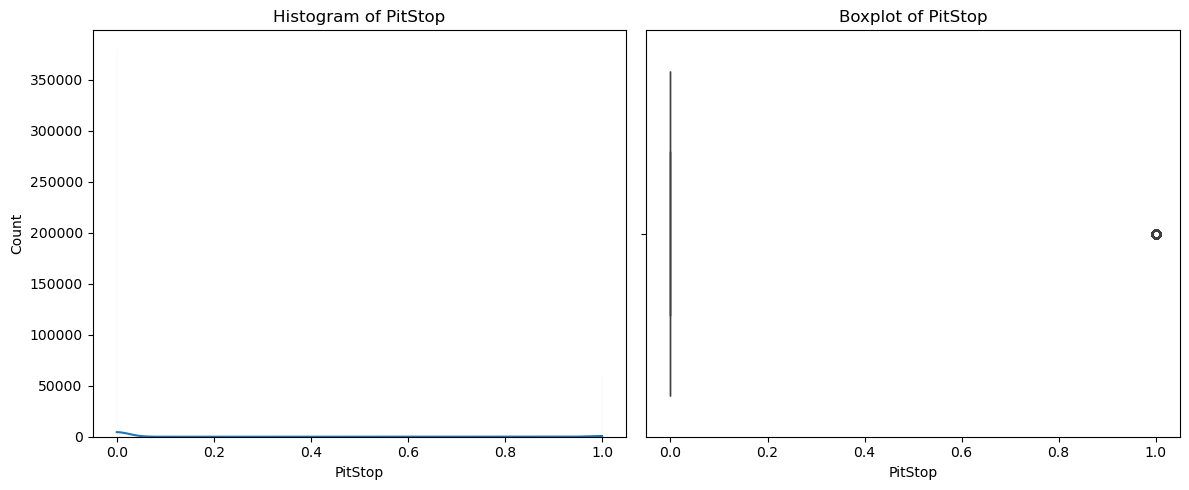

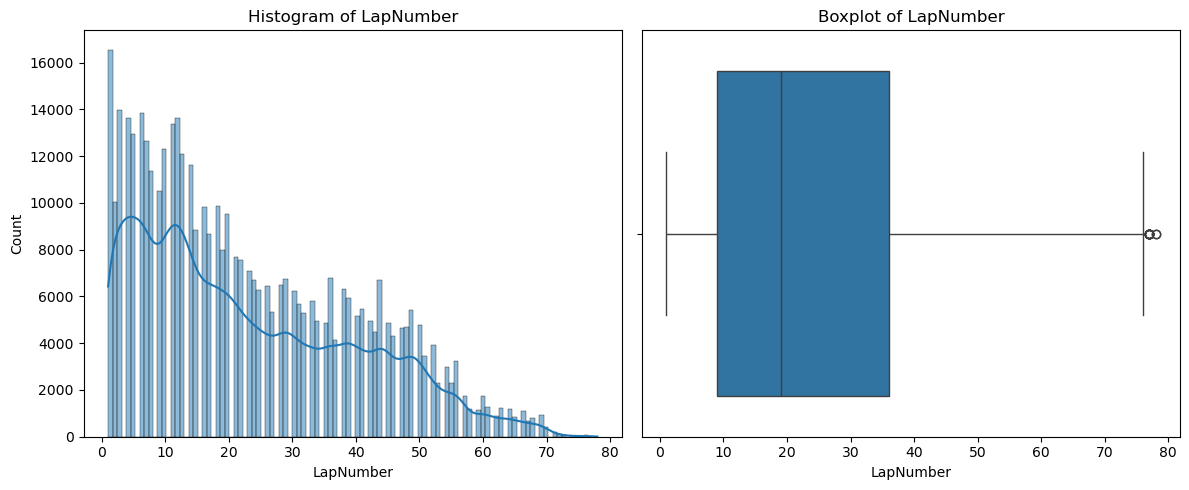

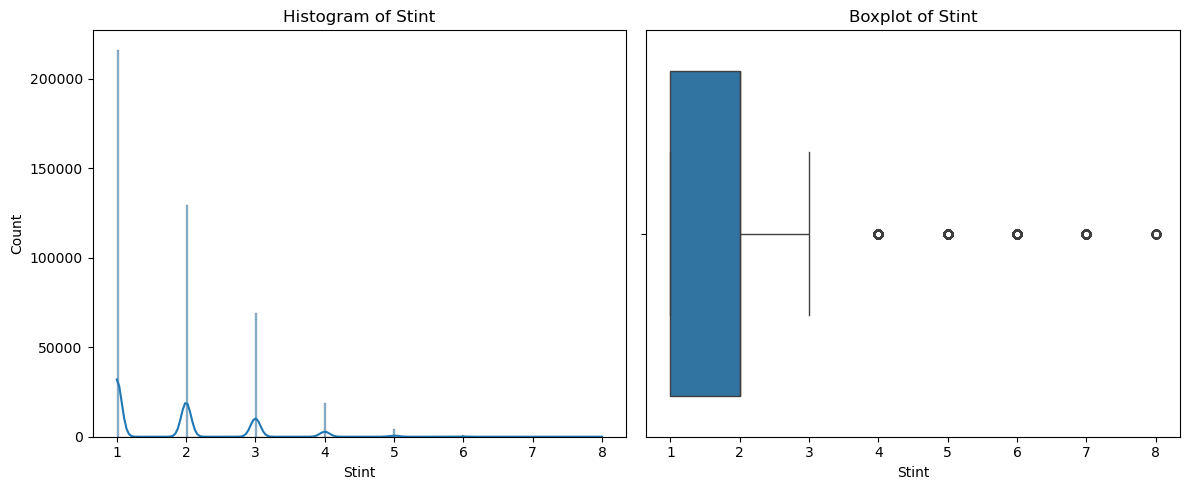

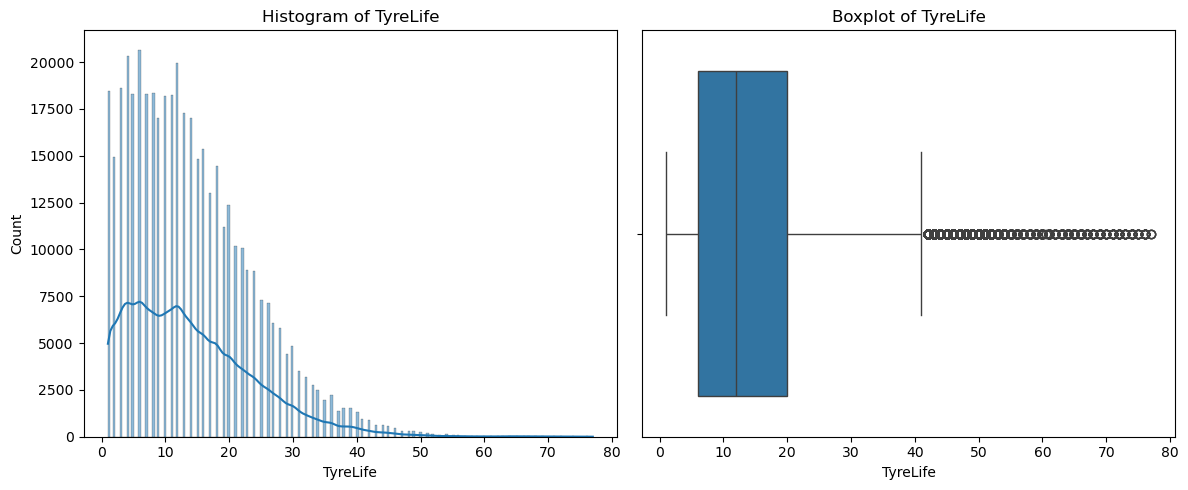

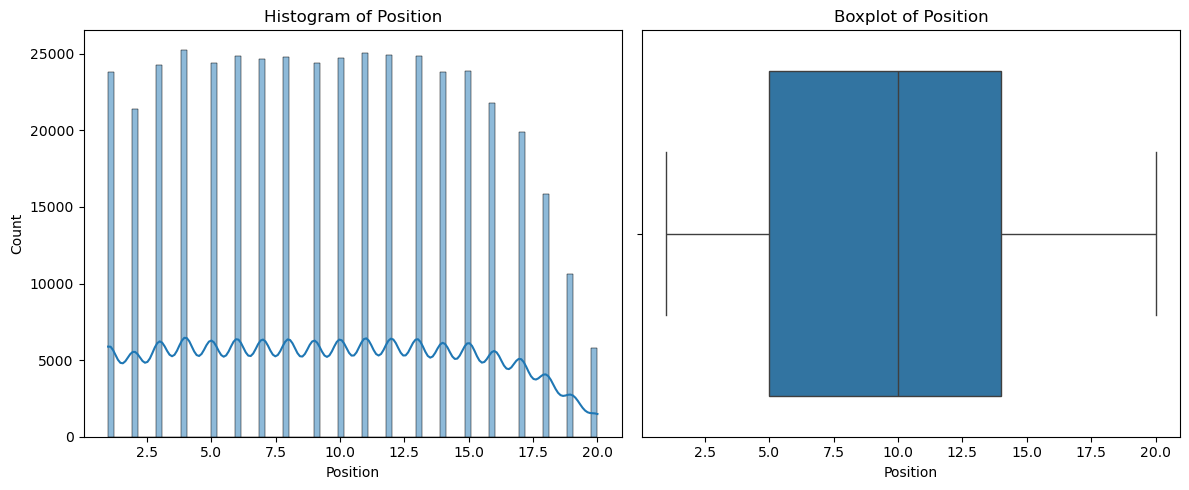

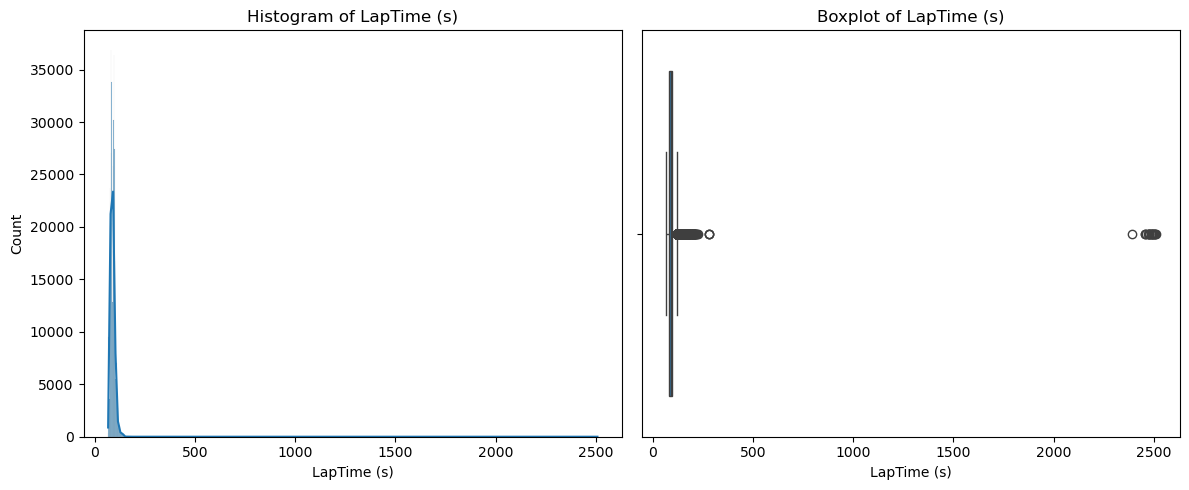

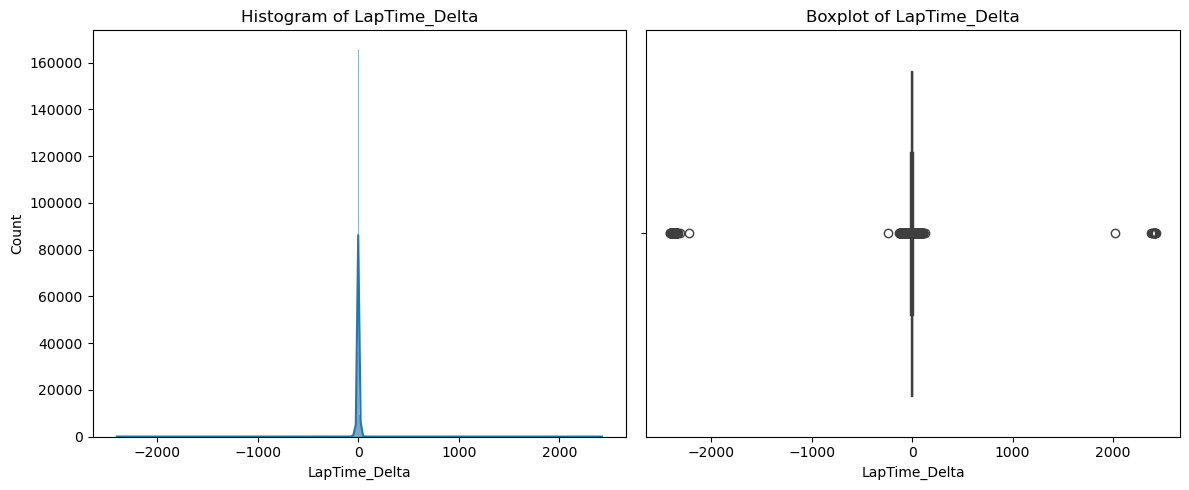

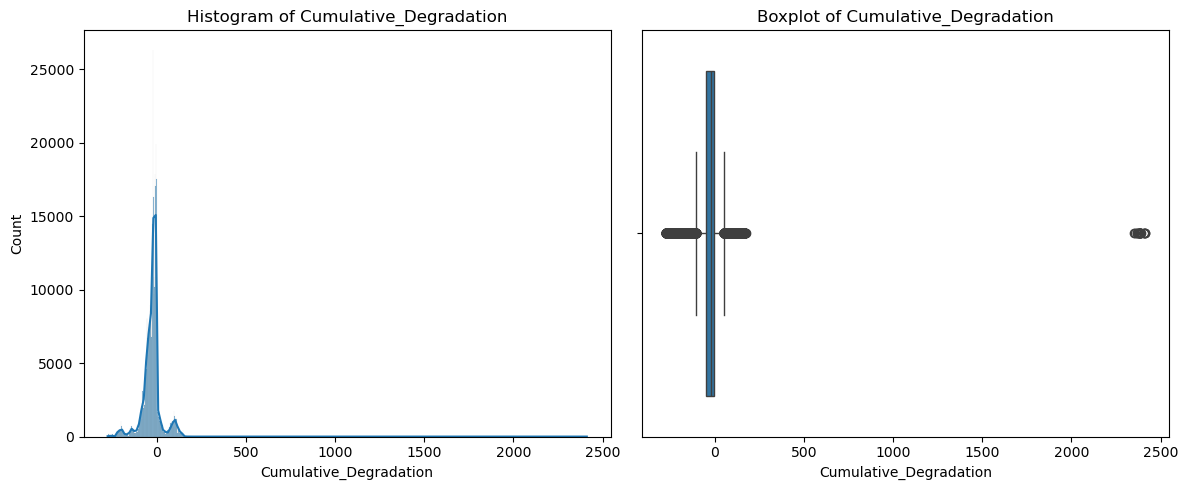

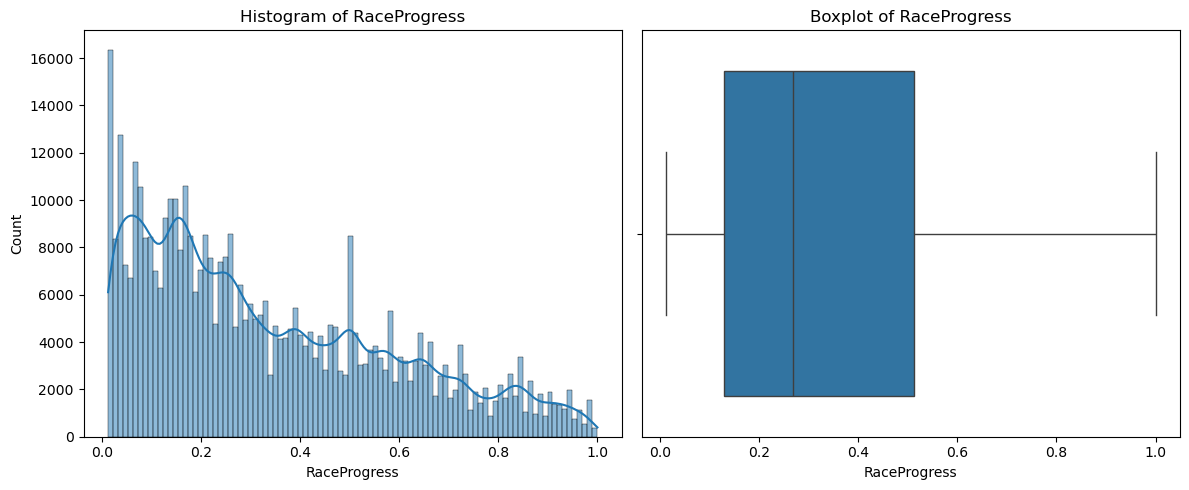

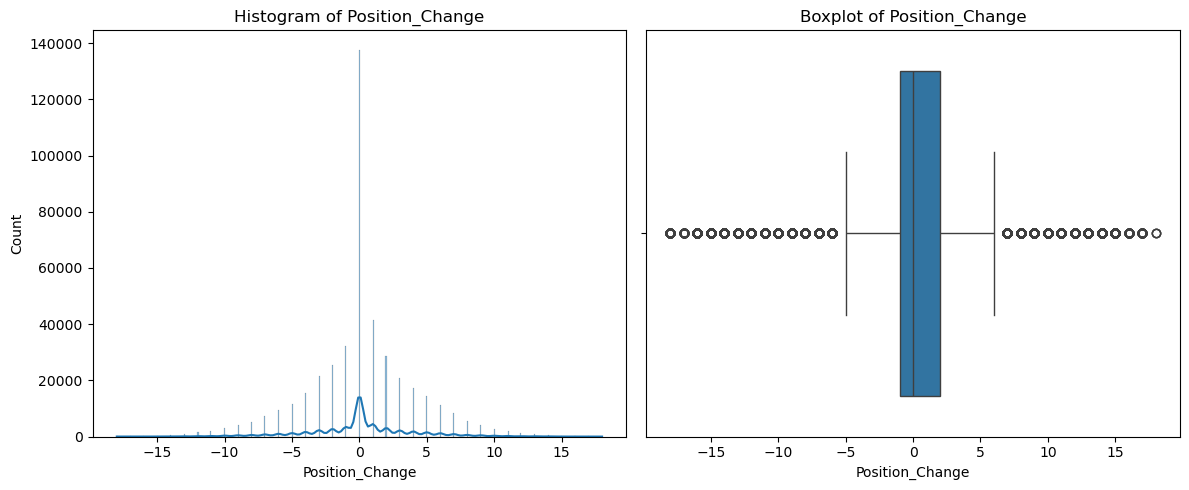

In [11]:
num_cols = df.select_dtypes(include='number').columns
num_cols = num_cols.drop(['id', 'PitNextLap'])
import seaborn as sns
import matplotlib.pyplot as plt
for col in num_cols:
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    sns.histplot(df[col], kde=True)
    plt.title(f"Histogram of {col}")
    plt.subplot(1,2,2)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()

### Handle Outliers

In [16]:
q1=df['LapTime (s)'].quantile(0.25)
q3=df['LapTime (s)'].quantile(0.75)
df['LapTime (s)']=df['LapTime (s)'].clip(q1,q3)

<Axes: ylabel='LapTime (s)'>

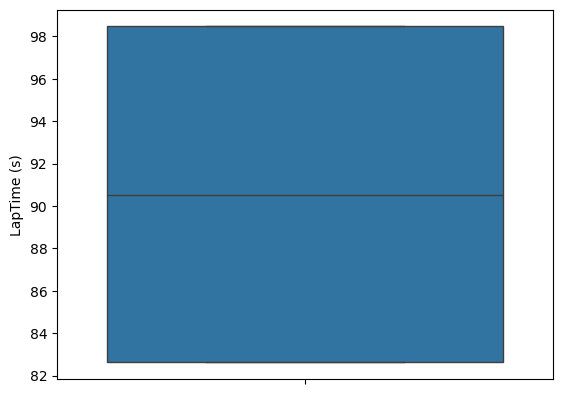

In [15]:
sns.boxplot(df['LapTime (s)'])

In [17]:
print(df['LapTime (s)'].describe())
print("Skewness:", df['LapTime (s)'].skew())

count    439140.000000
mean         90.392405
std           6.629248
min          82.621000
25%          82.621000
50%          90.521000
75%          98.471000
max          98.471000
Name: LapTime (s), dtype: float64
Skewness: 0.03663827589207347


count    439140.000000
mean         12.832705
std           5.624229
min           6.000000
25%           6.000000
50%          12.000000
75%          20.000000
max          20.000000
Name: TyreLife, dtype: float64
0.07303115208172817


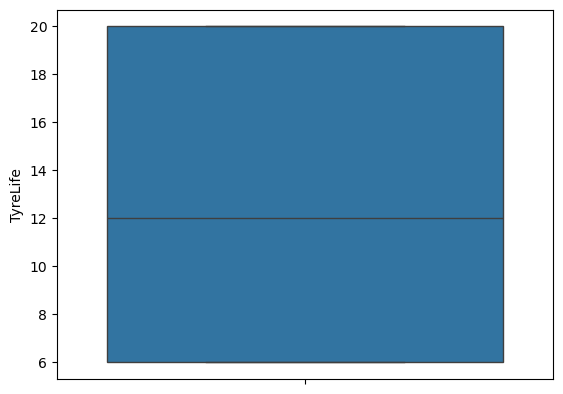

In [18]:
q1=df['TyreLife'].quantile(0.25)
q3=df['TyreLife'].quantile(0.75)
df['TyreLife']=df['TyreLife'].clip(q1,q3)
sns.boxplot(df['TyreLife'])
print(df['TyreLife'].describe())
print(df['TyreLife'].skew())

count    439140.000000
mean         -3.202197
std           3.910070
min          -8.884000
25%          -8.884000
50%          -0.295000
75%           0.115000
max           0.115000
Name: LapTime_Delta, dtype: float64
-0.5732478791432122


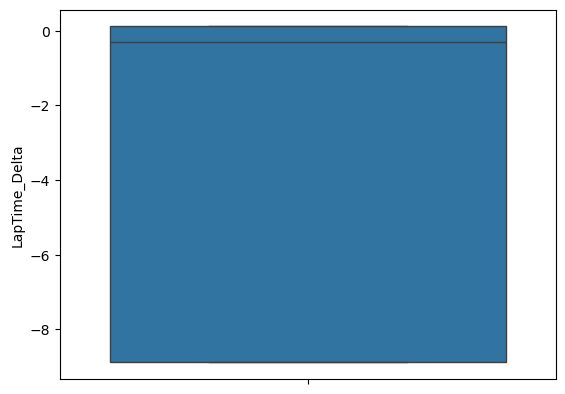

In [19]:
q1=df['LapTime_Delta'].quantile(0.25)
q3=df['LapTime_Delta'].quantile(0.75)
df['LapTime_Delta']=df['LapTime_Delta'].clip(q1,q3)
sns.boxplot(df['LapTime_Delta'])
print(df['LapTime_Delta'].describe())
print(df['LapTime_Delta'].skew())

-0.20993328861889993
count    439140.000000
mean        -24.790980
std          16.377651
min         -46.566250
25%         -46.566063
50%         -20.994000
75%          -6.199000
max          -6.199000
Name: Cumulative_Degradation, dtype: float64


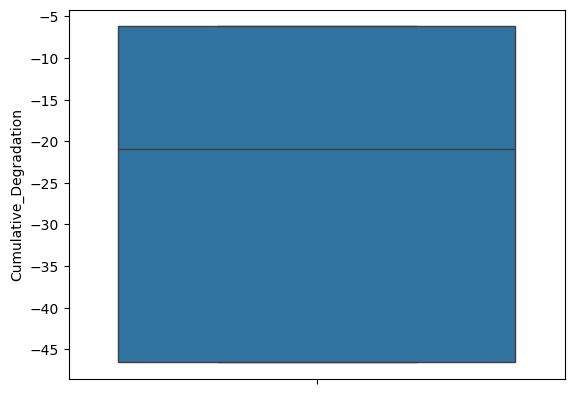

In [20]:
q1=df['Cumulative_Degradation'].quantile(0.25)
q3=df['Cumulative_Degradation'].quantile(0.75)
df['Cumulative_Degradation']=df['Cumulative_Degradation'].clip(q1,q3)
sns.boxplot(df['Cumulative_Degradation'])
print(df['Cumulative_Degradation'].skew())
print(df['Cumulative_Degradation'].describe())

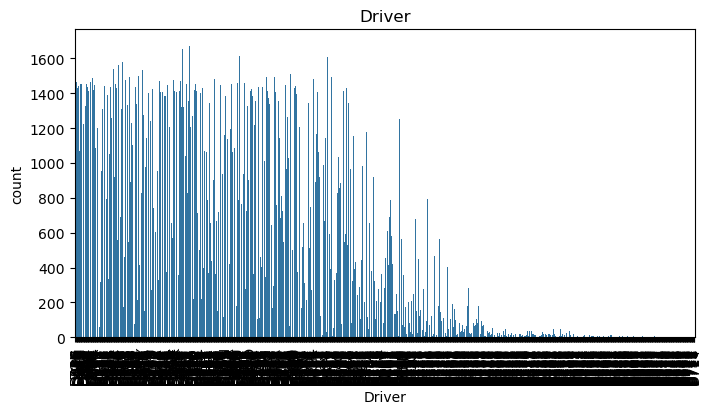

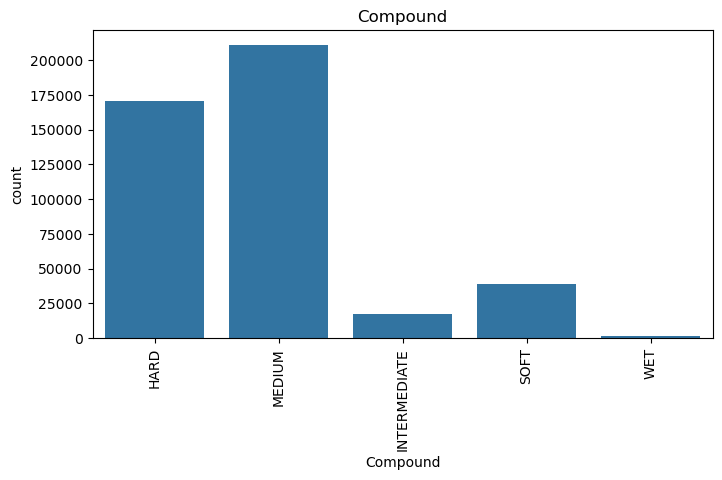

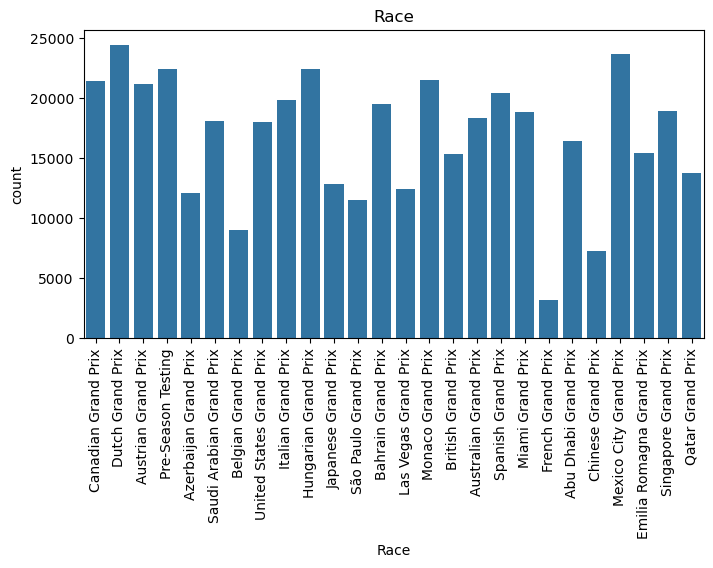

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=df[col])
    plt.xticks(rotation=90)
    plt.title(col)
    plt.show()

In [21]:
for col in num_cols:
    print(col,df[col].skew())

id 7.325567812990374e-17
Year -0.000610619683501735
PitStop 2.122297402251859
LapNumber 0.6459650188747419
Stint 1.1854786226203045
TyreLife 0.07303115208172817
Position 0.07009764457364438
LapTime (s) 0.03663827589207347
LapTime_Delta -0.5732478791432122
Cumulative_Degradation -0.20993328861889993
RaceProgress 0.6999501428857348
Position_Change -0.09271426725985094
PitNextLap 1.5079803487341805


### Step 7 BiVariate Analysis

In [22]:
pd.crosstab(df['Compound'], df['PitNextLap'], normalize='index') * 100

PitNextLap,0.0,1.0
Compound,,
HARD,67.246273,32.753727
INTERMEDIATE,84.771603,15.228397
MEDIUM,89.886853,10.113147
SOFT,80.652488,19.347512
WET,97.490775,2.509225


<Axes: xlabel='PitNextLap', ylabel='TyreLife'>

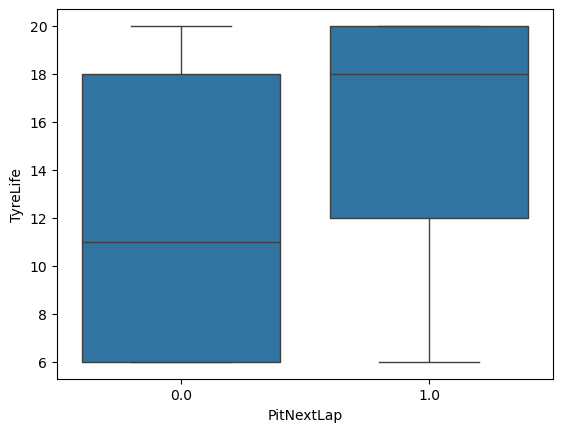

In [23]:
sns.boxplot(data=df, x='PitNextLap', y='TyreLife')

<Axes: xlabel='PitNextLap', ylabel='LapNumber'>

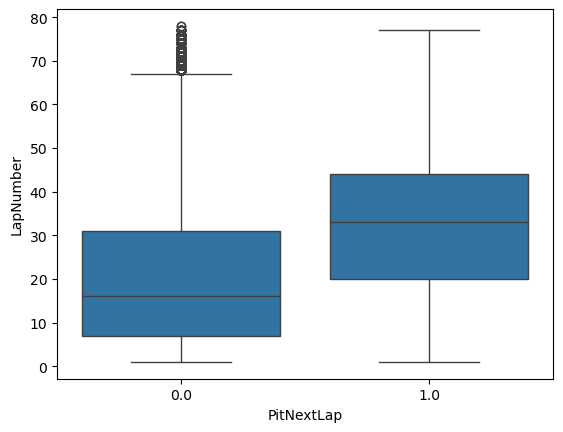

In [20]:
sns.boxplot(data=df, x='PitNextLap', y='LapNumber')

<Axes: xlabel='PitNextLap', ylabel='RaceProgress'>

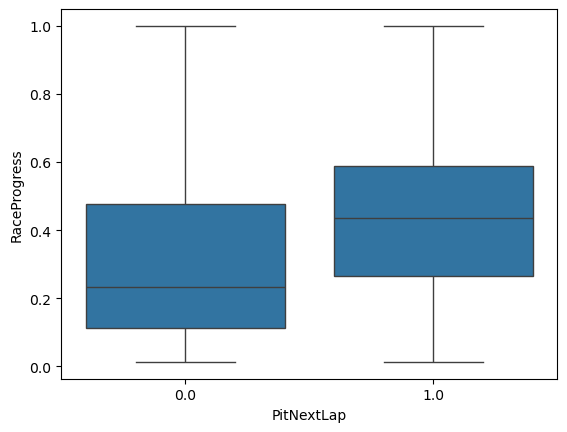

In [21]:
sns.boxplot(data=df, x='PitNextLap', y='RaceProgress')

<Axes: xlabel='PitNextLap', ylabel='Position'>

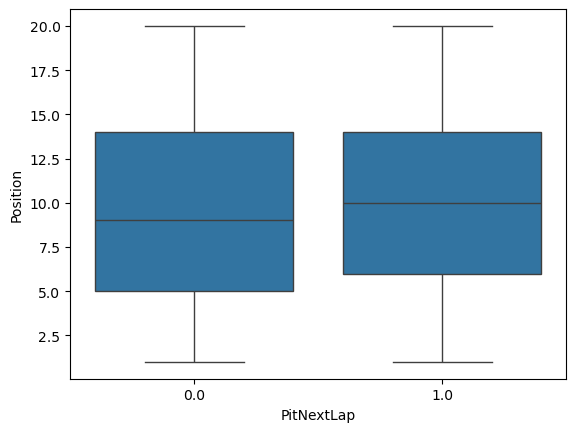

In [21]:
sns.boxplot(data=df, x='PitNextLap', y='Position')

### MultiVaraite Analysis

In [24]:
df['PitNextLap'].value_counts(normalize=True) * 100

PitNextLap
0.0    80.10179
1.0    19.89821
Name: proportion, dtype: float64

In [25]:
df['Driver'].value_counts(normalize=True)*100

Driver
MAS     0.383021
RAI     0.380061
BAR     0.377101
BUT     0.376873
FIS     0.375962
          ...   
D723    0.000228
D677    0.000228
D731    0.000228
D716    0.000228
D714    0.000228
Name: proportion, Length: 887, dtype: float64

In [26]:
df['Race'].nunique()

26

In [27]:
freq = df['Driver'].value_counts(normalize=True)
df['Driver'] = df['Driver'].map(freq)

In [28]:
df.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,0.002345,HARD,Canadian Grand Prix,2022,0,50,2,20.0,8,82.621,-7.564,-6.19900,0.714286,5.0,1.0
1,1,0.002671,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,82.621,-8.884,-46.56625,0.346154,-3.0,0.0
2,2,0.003336,HARD,Austrian Grand Prix,2022,0,59,3,20.0,13,82.621,-7.540,-46.56625,0.819444,3.0,1.0
3,3,0.003261,MEDIUM,Pre-Season Testing,2023,0,2,1,6.0,7,94.361,-7.324,-7.32400,0.076923,0.0,0.0
4,4,0.003316,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,98.471,0.115,-14.13900,0.361111,3.0,0.0


In [29]:
num_data=df.select_dtypes(include=np.number).drop('PitNextLap',axis=1)
cat_data=df.select_dtypes(exclude=np.number)
tar_data=df[['PitNextLap']]

In [30]:
encoded=pd.get_dummies(cat_data,drop_first=True)
final_df=pd.concat([num_data,encoded,tar_data],axis=1)

In [31]:
final_df.drop(columns='id',axis=1)

,Driver,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,...,Race_Miami Grand Prix,Race_Monaco Grand Prix,Race_Pre-Season Testing,Race_Qatar Grand Prix,Race_Saudi Arabian Grand Prix,Race_Singapore Grand Prix,Race_Spanish Grand Prix,Race_São Paulo Grand Prix,Race_United States Grand Prix,PitNextLap
0,0.002345,2022,0,50,2,20.0,8,82.621,-7.564,-6.19900,...,False,False,False,False,False,False,False,False,False,1.0
1,0.002671,2025,1,27,2,7.0,4,82.621,-8.884,-46.56625,...,False,False,False,False,False,False,False,False,False,0.0
2,0.003336,2022,0,59,3,20.0,13,82.621,-7.540,-46.56625,...,False,False,False,False,False,False,False,False,False,1.0
3,0.003261,2023,0,2,1,6.0,7,94.361,-7.324,-7.32400,...,False,False,True,False,False,False,False,False,False,0.0
4,0.003316,2022,1,26,3,6.0,2,98.471,0.115,-14.13900,...,False,False,False,False,False,False,False,False,False,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
439135,0.000002,2023,0,49,2,8.0,17,92.638,-0.076,-15.85900,...,True,False,False,False,False,False,False,False,False,0.0
439136,0.000002,2023,0,49,2,6.0,1,85.890,-0.083,-6.19900,...,True,False,False,False,False,False,False,False,False,0.0
439137,0.000002,2023,0,49,2,18.0,1,91.644,-0.182,-46.56625,...,True,False,False,False,False,False,False,False,False,0.0
439138,0.000005,2023,0,48,3,10.0,1,89.947,-0.001,-20.72100,...,False,False,False,False,False,False,False,False,False,0.0


In [30]:
final_df

,id,Driver,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,...,Race_Miami Grand Prix,Race_Monaco Grand Prix,Race_Pre-Season Testing,Race_Qatar Grand Prix,Race_Saudi Arabian Grand Prix,Race_Singapore Grand Prix,Race_Spanish Grand Prix,Race_São Paulo Grand Prix,Race_United States Grand Prix,PitNextLap
0,0,0.002345,2022,0,50,2,20.0,8,82.621,-7.564,...,False,False,False,False,False,False,False,False,False,1.0
1,1,0.002671,2025,1,27,2,7.0,4,82.621,-8.884,...,False,False,False,False,False,False,False,False,False,0.0
2,2,0.010008,2022,0,59,3,20.0,13,82.621,-7.540,...,False,False,False,False,False,False,False,False,False,1.0
3,3,0.003261,2023,0,2,1,6.0,7,94.361,-7.324,...,False,False,True,False,False,False,False,False,False,0.0
4,4,0.006631,2022,1,26,3,6.0,2,98.471,0.115,...,False,False,False,False,False,False,False,False,False,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
439135,439135,0.000169,2023,0,49,2,8.0,17,92.638,-0.076,...,True,False,False,False,False,False,False,False,False,0.0
439136,439136,0.000169,2023,0,49,2,6.0,1,85.890,-0.083,...,True,False,False,False,False,False,False,False,False,0.0
439137,439137,0.000169,2023,0,49,2,18.0,1,91.644,-0.182,...,True,False,False,False,False,False,False,False,False,0.0
439138,439138,0.000191,2023,0,48,3,10.0,1,89.947,-0.001,...,False,False,False,False,False,False,False,False,False,0.0


In [32]:
print(final_df.columns)

Index(['id', 'Driver', 'Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife',
       'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation',
       'RaceProgress', 'Position_Change', 'Compound_INTERMEDIATE',
       'Compound_MEDIUM', 'Compound_SOFT', 'Compound_WET',
       'Race_Australian Grand Prix', 'Race_Austrian Grand Prix',
       'Race_Azerbaijan Grand Prix', 'Race_Bahrain Grand Prix',
       'Race_Belgian Grand Prix', 'Race_British Grand Prix',
       'Race_Canadian Grand Prix', 'Race_Chinese Grand Prix',
       'Race_Dutch Grand Prix', 'Race_Emilia Romagna Grand Prix',
       'Race_French Grand Prix', 'Race_Hungarian Grand Prix',
       'Race_Italian Grand Prix', 'Race_Japanese Grand Prix',
       'Race_Las Vegas Grand Prix', 'Race_Mexico City Grand Prix',
       'Race_Miami Grand Prix', 'Race_Monaco Grand Prix',
       'Race_Pre-Season Testing', 'Race_Qatar Grand Prix',
       'Race_Saudi Arabian Grand Prix', 'Race_Singapore Grand Prix',
       'Race_Spanish Grand

In [33]:
x=final_df.drop('PitNextLap',axis=1)
y=final_df[['PitNextLap']]

In [35]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,train_size=0.7,test_size=0.3,random_state=42)
print(xtrain.shape)

(307398, 42)


In [36]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(xtrain)
x_test_scaled = scaler.transform(xtest)

In [48]:
import warnings
warnings.filterwarnings('ignore')

In [49]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
lr = LogisticRegression(random_state=42)
lr.fit(x_train_scaled,ytrain)
ytrain_lr=lr.predict(x_train_scaled)
ytest_lr=lr.predict(x_test_scaled)
print("Train Accuracy:",accuracy_score(ytrain,ytrain_lr))
print("Test Accuracy :", accuracy_score(ytest, ytest_lr))

Train Accuracy: 0.8470874891834039
Test Accuracy : 0.8480666757753792


In [51]:
print(classification_report(ytest,ytest_lr))

              precision    recall  f1-score   support

         0.0       0.87      0.95      0.91    105541
         1.0       0.68      0.45      0.54     26201

    accuracy                           0.85    131742
   macro avg       0.77      0.70      0.73    131742
weighted avg       0.84      0.85      0.84    131742



In [52]:
import mlflow
import mlflow.sklearn

In [69]:
mlflow.set_experiment("f1_pit_Stop_multi_model")

<Experiment: artifact_location='file:C:/Users/DELL/OneDrive/Desktop/ml f1/catboost_info/mlruns/1', creation_time=1784575147273, experiment_id='1', last_update_time=1784575147273, lifecycle_stage='active', name='f1_pit_Stop_multi_model', tags={}, trace_location=None, workspace='default'>

In [71]:
with mlflow.start_run(run_name="Logistic_Regresion"):
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
    lr = LogisticRegression(random_state=42)
    lr.fit(x_train_scaled,ytrain)
    ytrain_lr=lr.predict(x_train_scaled)
    ytest_lr=lr.predict(x_test_scaled)
    print("Train Accuracy:",accuracy_score(ytrain,ytrain_lr))
    print("Test Accuracy :", accuracy_score(ytest, ytest_lr))
    report_dict_lr = classification_report(ytest, ytest_lr, output_dict=True)  
    mlflow.log_metric("accuracy", accuracy_score(ytest, ytest_lr))
    mlflow.log_metric("precision_weighted", report_dict_lr["weighted avg"]["precision"])
    mlflow.log_metric("recall_weighted", report_dict_lr["weighted avg"]["recall"])
    mlflow.log_metric("f1_weighted", report_dict_lr["weighted avg"]["f1-score"])
    mlflow.sklearn.log_model(lr,artifact_path="model")
    print("lr run logged to MLflow")

2026/07/21 20:52:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Train Accuracy: 0.8470874891834039
Test Accuracy : 0.8480666757753792


2026/07/21 20:52:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


lr run logged to MLflow


In [43]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train_scaled,ytrain)
ytest_knn=knn.predict(x_test_scaled)
ytrain_knn=knn.predict(x_train_scaled)
print("Train Accuracy:",accuracy_score(ytrain,ytrain_knn))
print("Test Accuracy :",accuracy_score(ytest,ytest_knn))

Train Accuracy: 0.9062258049824657
Test Accuracy : 0.8719922272320141


In [55]:
from sklearn.svm import LinearSVC
svm = LinearSVC(random_state=42)
svm.fit(x_train_scaled, ytrain)
ytest_svc=svm.predict(x_test_scaled)
ytrain_svc=svm.predict(x_train_scaled)
print('accuracy:',accuracy_score(ytest,ytest_svc))
print('accuracy:',accuracy_score(ytrain,ytrain_svc))

accuracy: 0.8472393010581287
accuracy: 0.846309995510706


In [59]:
import warnings
warnings.filterwarnings('ignore')

In [72]:
with mlflow.start_run(run_name="LinearSVC"):
    from sklearn.svm import LinearSVC
    svm = LinearSVC(random_state=42)
    svm.fit(x_train_scaled, ytrain)
    ytest_svc=svm.predict(x_test_scaled)
    ytrain_svc=svm.predict(x_train_scaled)
    print('accuracy:',accuracy_score(ytest,ytest_svc))
    print('accuracy:',accuracy_score(ytrain,ytrain_svc))
    report_dict_svc = classification_report(ytest, ytest_svc, output_dict=True)  
    mlflow.log_metric("accuracy", accuracy_score(ytest, ytest_svc))
    mlflow.log_metric("precision_weighted", report_dict_svc["weighted avg"]["precision"])
    mlflow.log_metric("recall_weighted", report_dict_svc["weighted avg"]["recall"])
    mlflow.log_metric("f1_weighted", report_dict_svc["weighted avg"]["f1-score"])
    mlflow.sklearn.log_model(svm,artifact_path="model")
    print("svc run logged to MLflow")

2026/07/21 20:52:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/21 20:52:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


accuracy: 0.8472393010581287
accuracy: 0.846309995510706
svc run logged to MLflow


In [45]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier(max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
dt.fit(xtrain,ytrain)
ytrain_dt=dt.predict(xtrain)
ytest_dt=dt.predict(xtest)
print('train acc:',accuracy_score(ytrain,ytrain_dt))
print('test acc:',accuracy_score(ytest,ytest_dt))

train acc: 0.8838574096122942
test acc: 0.8790818417816642


In [57]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,random_state=42)
rf.fit(xtrain,ytrain)
ytrain_rf=rf.predict(xtrain)
ytest_rf=rf.predict(xtest)
print(accuracy_score(ytrain,ytrain_rf))
print(accuracy_score(ytest,ytest_rf))

0.8992413743745893
0.8864523082995552


In [64]:
print(classification_report(ytest,ytest_rf))
print(confusion_matrix(ytest,ytest_rf))

              precision    recall  f1-score   support

         0.0       0.92      0.94      0.93    105541
         1.0       0.73      0.68      0.70     26201

    accuracy                           0.89    131742
   macro avg       0.83      0.81      0.82    131742
weighted avg       0.88      0.89      0.88    131742

[[99080  6461]
 [ 8498 17703]]


In [73]:
with mlflow.start_run(run_name="RandomForestClassifier"):
    from sklearn.ensemble import RandomForestClassifier
    rf=RandomForestClassifier(n_estimators=200,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=5,random_state=42)
    rf.fit(xtrain,ytrain)
    ytrain_rf=rf.predict(xtrain)
    ytest_rf=rf.predict(xtest)
    print(accuracy_score(ytrain,ytrain_rf))
    print(accuracy_score(ytest,ytest_rf))
    report_dict_rf=classification_report(ytest,ytest_rf,output_dict=True)
    mlflow.log_metric("accuracy",accuracy_score(ytest,ytest_rf))
    mlflow.log_metric("precision_weighted", report_dict_rf["weighted avg"]["precision"])
    mlflow.log_metric("recall_weighted", report_dict_rf["weighted avg"]["recall"])
    mlflow.log_metric("f1_weighted", report_dict_rf["weighted avg"]["f1-score"])
    mlflow.sklearn.log_model(rf,artifact_path="model")
    print("rf run logged to MLflow")

2026/07/21 20:55:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/21 20:55:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


0.8992413743745893
0.8864523082995552
rf run logged to MLflow


In [63]:
from xgboost import XGBClassifier
xgb=XGBClassifier(n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss')
xgb.fit(xtrain,ytrain)
ytrain_pred=xgb.predict(xtrain)
ytest_pred=xgb.predict(xtest)
print("accuray_Score:",accuracy_score(ytrain,ytrain_pred))
print("accuracy_score:",accuracy_score(ytest,ytest_pred))

accuray_Score: 0.8981873662157854
accuracy_score: 0.8931168495999757


In [37]:
print(classification_report(ytest,ytest_pred))
print(confusion_matrix(ytest,ytest_pred))

              precision    recall  f1-score   support

         0.0       0.93      0.94      0.93    105541
         1.0       0.74      0.72      0.73     26201

    accuracy                           0.89    131742
   macro avg       0.83      0.83      0.83    131742
weighted avg       0.89      0.89      0.89    131742

[[98909  6632]
 [ 7449 18752]]


In [79]:
with mlflow.start_run(run_name="XGBClassifier"):
    from xgboost import XGBClassifier
    xgb=XGBClassifier(n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss')
    xgb.fit(xtrain,ytrain)
    ytrain_pred=xgb.predict(xtrain)
    ytest_pred=xgb.predict(xtest)
    print("accuray_Score:",accuracy_score(ytrain,ytrain_pred))
    print("accuracy_score:",accuracy_score(ytest,ytest_pred))
    report_dict_xgb=classification_report(ytest,ytest_pred,output_dict=True)
    mlflow.log_metric("accuracy",accuracy_score(ytest,ytest_pred))
    mlflow.log_metric("precision_weighted", report_dict_xgb["weighted avg"]["precision"])
    mlflow.log_metric("recall_weighted", report_dict_xgb["weighted avg"]["recall"])
    mlflow.log_metric("f1_weighted", report_dict_xgb["weighted avg"]["f1-score"])
    
    mlflow.sklearn.log_model(xgb,artifact_path="model")
    print("xgb run logged to MLflow")

accuray_Score: 0.8981873662157854
accuracy_score: 0.8931168495999757


2026/07/21 22:34:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/21 22:34:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


xgb run logged to MLflow


### After Smote Analysis 

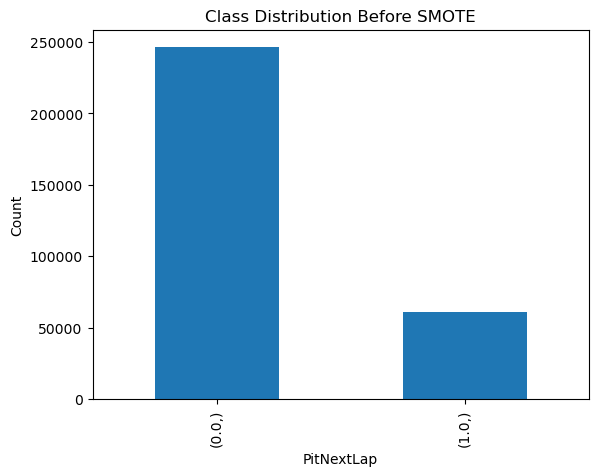

In [39]:
import matplotlib.pyplot as plt

ytrain.value_counts().plot(kind='bar')

plt.title("Class Distribution Before SMOTE")
plt.xlabel("PitNextLap")
plt.ylabel("Count")
plt.show()

In [55]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

xtrain_smote, ytrain_smote = smote.fit_resample(xtrain, ytrain)

In [41]:
print(ytrain_smote.value_counts())

PitNextLap
0.0           246218
1.0           246218
Name: count, dtype: int64


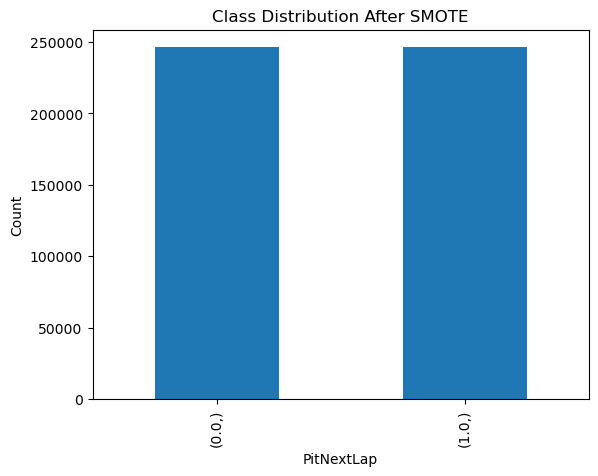

In [61]:
import matplotlib.pyplot as plt

ytrain_smote.value_counts().plot(kind='bar')

plt.title("Class Distribution After SMOTE")
plt.xlabel("PitNextLap")
plt.ylabel("Count")
plt.show()

In [44]:
lr.fit(xtrain_smote, ytrain_smote)
ytrain_lr = lr.predict(xtrain_smote)
ytest_lr = lr.predict(xtest)
print("Train Accuracy:", accuracy_score(ytrain_smote, ytrain_lr))
print("Test Accuracy :", accuracy_score(ytest, ytest_lr))

Train Accuracy: 0.7035513244360688
Test Accuracy : 0.6820148472013481


In [45]:
print(classification_report(ytest, ytest_lr))

              precision    recall  f1-score   support

         0.0       0.90      0.68      0.77    105541
         1.0       0.35      0.70      0.47     26201

    accuracy                           0.68    131742
   macro avg       0.63      0.69      0.62    131742
weighted avg       0.79      0.68      0.71    131742



In [63]:
print(classification_report(ytest,ytest_pred))

              precision    recall  f1-score   support

         0.0       0.93      0.93      0.93    105541
         1.0       0.70      0.71      0.71     26201

    accuracy                           0.88    131742
   macro avg       0.82      0.82      0.82    131742
weighted avg       0.88      0.88      0.88    131742



In [52]:
rf.fit(xtrain_smote, ytrain_smote)
ytrain_rf=rf.predict(xtrain_smote)
ytest_rf=rf.predict(xtest)
print(accuracy_score(ytrain_smote,ytrain_rf))
print(accuracy_score(ytest,ytest_rf))

0.9140314680486398
0.8700566258292723


In [62]:
print(classification_report(ytest,ytest_rf))

              precision    recall  f1-score   support

         0.0       0.95      0.89      0.92    105541
         1.0       0.64      0.80      0.71     26201

    accuracy                           0.87    131742
   macro avg       0.79      0.84      0.81    131742
weighted avg       0.89      0.87      0.88    131742



In [83]:
predictions=xgb.predict(xtest)

In [84]:
test = pd.read_csv('test.csv')

In [96]:
print(test.shape)
print(test.columns)

(188165, 15)
Index(['id', 'Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber',
       'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta',
       'Cumulative_Degradation', 'RaceProgress', 'Position_Change'],
      dtype='object')


In [ ]:
x=final_df.drop('PitNextLap',axis=1)
y=final_df[['PitNextLap']]

In [ ]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,train_size=0.7,test_size=0.3,random_state=42)
print(xtrain.shape)

In [111]:
freq = test["Driver"].value_counts()
test["Driver"] = test["Driver"].map(freq)

In [103]:
test_ids = test["id"]

In [113]:
test = pd.get_dummies(test, columns=["Compound", "Race"], drop_first=True)

KeyError: "None of [Index(['Compound', 'Race'], dtype='object')] are in the [columns]"

In [114]:
test = test.reindex(columns=x.columns, fill_value=0)

In [115]:
test.head()

,id,Driver,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,...,Race_Mexico City Grand Prix,Race_Miami Grand Prix,Race_Monaco Grand Prix,Race_Pre-Season Testing,Race_Qatar Grand Prix,Race_Saudi Arabian Grand Prix,Race_Singapore Grand Prix,Race_Spanish Grand Prix,Race_São Paulo Grand Prix,Race_United States Grand Prix
0,439140,1191,2023,0,21,1,21.0,4,93.387,0.280,...,False,False,False,False,False,False,False,False,False,False
1,439141,1200,2023,0,24,1,24.0,1,90.867,-0.129,...,False,False,False,False,False,False,False,False,False,False
2,439142,256,2023,0,24,1,24.0,11,92.871,0.041,...,False,False,False,False,False,False,False,False,False,False
3,439143,409,2024,0,6,2,4.0,15,94.967,-19.741,...,False,False,False,False,False,False,False,False,True,False
4,439144,2476,2024,0,52,2,29.0,12,99.112,0.930,...,False,False,False,False,False,False,False,False,False,True


In [107]:
test.shape

(188165, 42)

In [110]:
predictions = xgb.predict(test)
submission = pd.DataFrame({
    "id": test_ids,
    "PitNextLap": predictions
})

submission.to_csv("submission.csv", index=False)